In [20]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import utils
from astropy.cosmology import Planck15
from astropy import units as u
import arepo_package as arepo

In [21]:
import scienceplots
plt.style.use(['science'])
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [22]:
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/SM5_TNG"

In [23]:
def z_to_tlookback(z):
    """Convert redshift to lookback time in Gyr using Planck15 cosmology."""
    return Planck15.lookback_time(z).value  # returns time in Gyr

In [24]:
def get_scale_factors(basePath, filename="output_scale_factors.txt"):
    path = basePath.split('/output')[0]
    #print(path)
    f = open(path+"/"+filename,'r')
    snaptimes = np.array([float(line) for line in f.readlines()])
    f.close()
    print(f"snapshot scale factors in {path}:")
    return snaptimes

In [25]:
TNG_scalefactors = get_scale_factors(TNG_basepath)
z = 1/TNG_scalefactors - 1                  
tlook_TNG = z_to_tlookback(z)
deltat_TNG = tlook_TNG[:-1]-tlook_TNG[1:]
snaps_TNG = np.arange(len(TNG_scalefactors))

snapshot scale factors in /orange/lblecha/IllustrisTNG/Runs/TNG50-1:


In [27]:
#brahma snapshots
snap,red = arepo.get_snapshot_redshift_correspondence(brahma_basepath)
brahma_tlook = z_to_tlookback(red)
brahma_deltat = brahma_tlook[:-1]-brahma_tlook[1:]

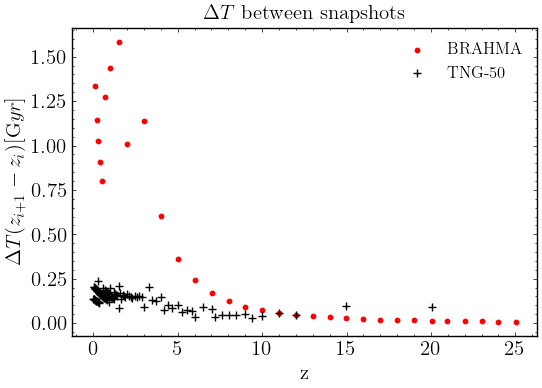

In [29]:
hostplot.set_plot_style(spinewidth=1, linewidth=1, titlesize=15, labelsize=15, xlabelsize=15, ylabelsize=15, legendsize=12, bold=True)
plt.figure(figsize=(6,4))
plt.scatter(red[:-1],brahma_deltat,marker="o",s=10,c="red",label="BRAHMA")
plt.scatter(z[:-1],deltat_TNG,marker="+",c="k",label="TNG-50")
#plt.axhline(1,color="k",linestyle="--")
#plt.xlim(0,5)
plt.xlabel("z")
plt.title("$\Delta T$ between snapshots")
plt.legend()
plt.ylabel("$\Delta T (z_{i+1} - z_{i}) [\mathrm Gyr]$")
plt.savefig("../../figures/Brahma_vs_TNG50_time_delay.pdf")